In [4]:
## Data Exploration and Cleaning

In [6]:
import pandas as pd

# Load the CSV file
file_path = "house_price_prediction_dataset.csv"
df = pd.read_csv(file_path)

In [7]:
# Display shape
print("--- Shape ---")
print(df.shape)

--- Shape ---
(125, 9)


In [5]:
# Display data types
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
House_ID                     int64
Area_m2                    float64
Bedrooms                   float64
Bathrooms                  float64
House_Age_Years            float64
Distance_to_City_km        float64
Parking_Spaces             float64
Neighborhood                   str
House_Price_Million_RWF    float64
dtype: object


In [7]:
df = pd.read_csv('house_price_prediction_dataset.csv')
print(df.head())

   House_ID  Area_m2  Bedrooms  Bathrooms  House_Age_Years  \
0      1001    144.6       2.0        2.0             15.0   
1      1002    101.9       4.0        4.0             15.5   
2      1003    157.1       3.0        2.0              8.9   
3      1004    254.2       3.0        2.0             15.5   
4      1005     96.7       3.0        2.0              9.5   

   Distance_to_City_km  Parking_Spaces Neighborhood  House_Price_Million_RWF  
0                27.40             0.0  Kigali City                    104.8  
1                 5.97             1.0         Huye                    137.0  
2                 2.42             1.0   Nyarugenge                    171.6  
3                 6.68             1.0      Musanze                    197.2  
4                12.34             2.0       Gasabo                    121.8  


In [5]:

import os
import pandas as pd

# Step 1: Display current working directory
print("Current directory:", os.getcwd())

# Step 2: Search for the dataset on your Desktop
file_path = None

for root, dirs, files in os.walk(r"C:\Users\Mugabe\Desktop"):
    if "Student_Dataset_Dirty.csv" in files:
        file_path = os.path.join(root, "Student_Dataset_Dirty.csv")
        break

# Step 3: Load the dataset and display results
if file_path:
    print("Dataset found:", file_path)

    df = pd.read_csv(file_path)

    # Display first five rows
    print("\nFirst five rows:")
    display(df.head())

    # Display dataset information
    print("\nDataset shape:", df.shape)

    # Display missing values
    print("\nMissing Values:")
    display(df.isnull().sum().to_frame("Missing Values"))

else:
    print("Dataset not found on Desktop.")
    print("Please check the file name or save it on your Desktop.")

Current directory: C:\Users\Mugabe\Desktop\DEO\MLassignment
Dataset found: C:\Users\Mugabe\Desktop\DEO\pyton\Student_Dataset_Dirty.csv

First five rows:


,Student_ID,Gender,Age,Campus,Study_Hours_Per_Week,Attendance_Percent,Previous_Score,Final_Mark,Internet_Access,Preferred_Learning_Mode,Submission_Date,Temporary_Note
0,ST001,Male,21.0,Kigali,8.0,92.0,68,74.0,Yes,Online,2026-09-01,remove
1,ST002,female,22.0,kigali,6.0,85.0,72,70.0,yes,Blended,2026/09/02,remove
2,ST003,FEMALE,20.0,KIGALI,10.0,96.0,81,86.0,YES,Face-to-face,03-09-2026,remove
3,ST004,M,23.0,Nyagatare,4.0,78.0,60,62.0,No,Face to Face,2026-09-04,remove
4,ST005,Male,NaN,Nyagatare,7.0,88.0,65,71.0,no,online,2026-09-05,remove



Dataset shape: (37, 12)

Missing Values:


,Missing Values
Student_ID,0
Gender,0
Age,1
Campus,0
Study_Hours_Per_Week,1
Attendance_Percent,1
Previous_Score,0
Final_Mark,1
Internet_Access,0
Preferred_Learning_Mode,0


In [6]:
print("--- INFO ---")
df.info()
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               37 non-null     str    
 1   Gender                   37 non-null     str    
 2   Age                      36 non-null     float64
 3   Campus                   37 non-null     str    
 4   Study_Hours_Per_Week     36 non-null     float64
 5   Attendance_Percent       36 non-null     float64
 6   Previous_Score           37 non-null     int64  
 7   Final_Mark               36 non-null     float64
 8   Internet_Access          37 non-null     str    
 9   Preferred_Learning_Mode  37 non-null     str    
 10  Submission_Date          37 non-null     str    
 11  Temporary_Note           37 non-null     str    
dtypes: float64(4), int64(1), str(7)
memory usage: 5.2 KB

--- SUMMARY STATISTICS ---
             Age  Study_Hours_Per_Week  Attendance_Pe

In [7]:
# Missing values count and percentage
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct.round(2)
})

print("=== MISSING VALUE SUMMARY ===")
print(missing_df.to_markdown())

print("\n=== ROWS WITH ANY MISSING VALUE ===")
null_rows = df[df.isnull().any(axis=1)]
print(null_rows.to_markdown())

=== MISSING VALUE SUMMARY ===
|                         |   Missing Count |   Missing Percentage (%) |
|:------------------------|----------------:|-------------------------:|
| Student_ID              |               0 |                      0   |
| Gender                  |               0 |                      0   |
| Age                     |               1 |                      2.7 |
| Campus                  |               0 |                      0   |
| Study_Hours_Per_Week    |               1 |                      2.7 |
| Attendance_Percent      |               1 |                      2.7 |
| Previous_Score          |               0 |                      0   |
| Final_Mark              |               1 |                      2.7 |
| Internet_Access         |               0 |                      0   |
| Preferred_Learning_Mode |               0 |                      0   |
| Submission_Date         |               0 |                      0   |
| Temporary_Note     

In [10]:
# Check exact duplicate rows
exact_duplicates = df.duplicated()
print(f"Exact Duplicate Rows Count: {exact_duplicates.sum()}")

# Check duplicates excluding House_ID
feature_duplicates = df.duplicated(subset=[col for col in df.columns if col != 'House_ID'])
print(f"Feature Duplicate Rows Count (excluding House_ID): {feature_duplicates.sum()}")

# Check duplicate House_IDs
id_duplicates = df['House_ID'].duplicated()
print(f"Duplicate House_IDs Count: {id_duplicates.sum()}")

if exact_duplicates.sum() > 0:
    print("\nExact Duplicates:")
    print(df[exact_duplicates])

if feature_duplicates.sum() > 0:
    print("\nFeature Duplicates:")
    print(df[feature_duplicates])

Exact Duplicate Rows Count: 5
Feature Duplicate Rows Count (excluding House_ID): 5
Duplicate House_IDs Count: 5

Exact Duplicates:
     House_ID  Area_m2  Bedrooms  Bathrooms  House_Age_Years  \
120      1011     85.3       1.0        1.0              8.7   
121      1026    116.9       5.0        4.0              5.0   
122      1041    165.1       5.0        5.0              6.2   
123      1011     85.3       1.0        1.0              8.7   
124      1026    116.9       5.0        4.0              5.0   

     Distance_to_City_km  Parking_Spaces Neighborhood  House_Price_Million_RWF  
120                 0.93             2.0       Gasabo                     99.8  
121                14.11             0.0         Huye                    140.4  
122                 8.84             0.0         Huye                    236.2  
123                 0.93             2.0       Gasabo                     99.8  
124                14.11             0.0         Huye                    140.4 

In [8]:
import pandas as pd
import numpy as np

# Use the correct file name that is actually present in the directory
df = pd.read_csv('house_price_prediction_dataset.csv')
df = df.drop_duplicates()

print("--- DETECTING OUTLIERS & IMPOSSIBLE VALUES ---")

# 1. Area_m2
print("\n[Area_m2]")
print("Extremely large values (> 500 m²):")
print(df[df['Area_m2'] > 500][['House_ID', 'Area_m2', 'House_Price_Million_RWF']])

# 2. Distance_to_City_km
print("\n[Distance_to_City_km]")
print("Extremely large values (> 20 km):")
print(df[df['Distance_to_City_km'] > 20][['House_ID', 'Distance_to_City_km', 'Neighborhood', 'House_Price_Million_RWF']])

# 3. House_Age_Years
print("\n[House_Age_Years]")
print("Extremely old houses (> 30 years):")
print(df[df['House_Age_Years'] > 30][['House_ID', 'House_Age_Years', 'House_Price_Million_RWF']])

# 4. House_Price_Million_RWF
print("\n[House_Price_Million_RWF]")
print("Extremely high prices (> 500 Million RWF):")
print(df[df['House_Price_Million_RWF'] > 500][['House_ID', 'Area_m2', 'House_Price_Million_RWF', 'Neighborhood']])

--- DETECTING OUTLIERS & IMPOSSIBLE VALUES ---

[Area_m2]
Extremely large values (> 500 m²):
    House_ID  Area_m2  House_Price_Million_RWF
5       1006    850.0                    150.2
18      1019   1200.0                    152.9

[Distance_to_City_km]
Extremely large values (> 20 km):
    House_ID  Distance_to_City_km Neighborhood  House_Price_Million_RWF
0       1001                27.40  Kigali City                    104.8
36      1037                21.09      Musanze                     89.9
47      1048                85.00   Nyarugenge                    199.6

[House_Age_Years]
Extremely old houses (> 30 years):
     House_ID  House_Age_Years  House_Price_Million_RWF
23       1024             30.9                     81.1
33       1034             75.0                    179.6
61       1062             32.9                    143.3
62       1063             49.5                     92.7
67       1068             31.2                    186.4
108      1109             34.3 

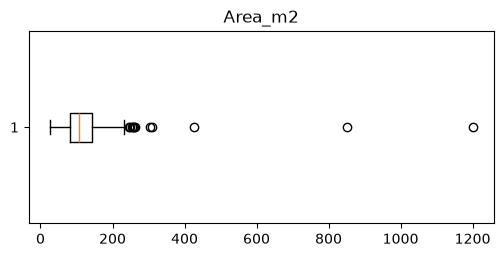

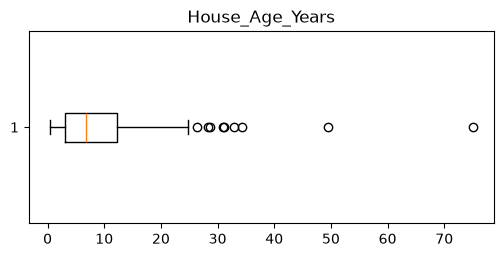

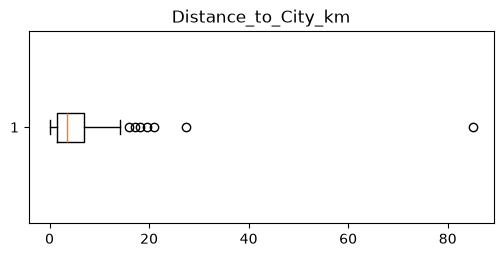

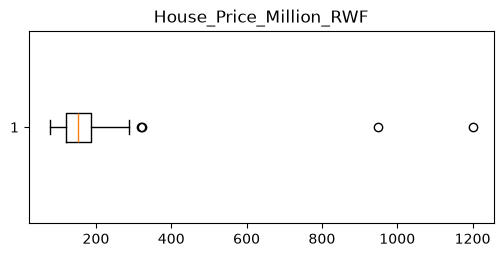

In [12]:
import matplotlib.pyplot as plt

for col in ["Area_m2", "House_Age_Years", "Distance_to_City_km", "House_Price_Million_RWF"]:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(df[col].dropna(), orientation="horizontal")
    plt.title(col)
    plt.show()

In [13]:
df=df.dropna(subset=["House_Price_Million_RWF"]).copy()
df=df[~df["House_ID"].isin([1006,1019,1034,1048,1073,1092])].copy()
numeric_features=["Area_m2","Bedrooms","Bathrooms","House_Age_Years","Distance_to_City_km","Parking_Spaces"]
for c in numeric_features: df[c]=df[c].fillna(df[c].median())
df["Neighborhood"]=df["Neighborhood"].fillna(df["Neighborhood"].mode()[0])
df.to_csv("house_price_prediction_cleaned.csv",index=False)
print(df.shape); display(df.isnull().sum())

(113, 9)


House_ID                   0
Area_m2                    0
Bedrooms                   0
Bathrooms                  0
House_Age_Years            0
Distance_to_City_km        0
Parking_Spaces             0
Neighborhood               0
House_Price_Million_RWF    0
dtype: int64

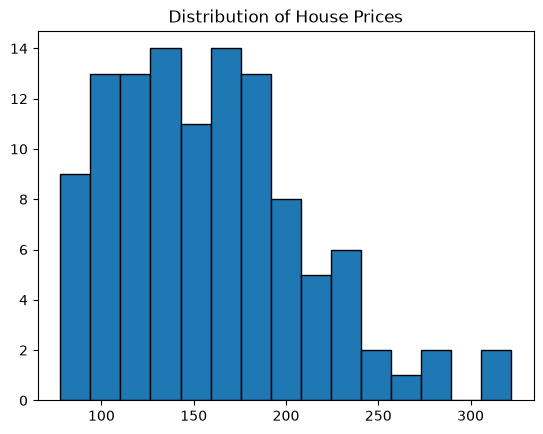

In [14]:
plt.hist(df["House_Price_Million_RWF"],bins=15,edgecolor="black");plt.title("Distribution of House Prices");plt.show()
# Interpretation: Most cleaned prices are in the lower-to-middle range, with fewer high-price houses.

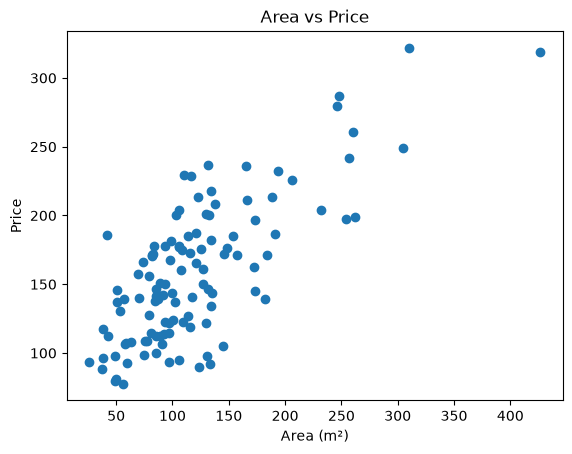

In [15]:
plt.scatter(df["Area_m2"],df["House_Price_Million_RWF"]);plt.xlabel("Area (m²)");plt.ylabel("Price");plt.title("Area vs Price");plt.show()
# Interpretation: Price generally increases as floor area increases.

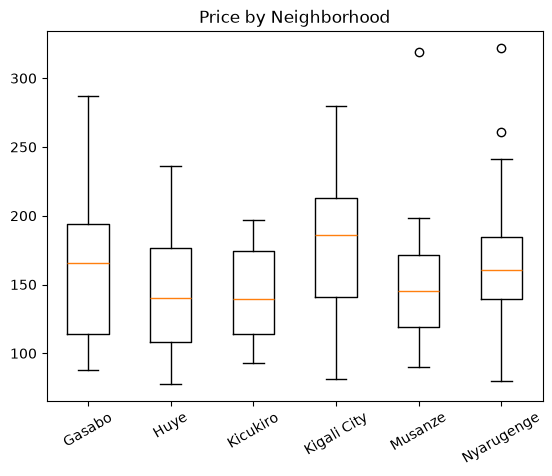

In [16]:
names=sorted(df["Neighborhood"].unique()); groups=[df.loc[df["Neighborhood"]==n,"House_Price_Million_RWF"] for n in names]
plt.boxplot(groups,tick_labels=names);plt.xticks(rotation=30);plt.title("Price by Neighborhood");plt.show()
# Interpretation: Price distributions differ across neighborhoods.

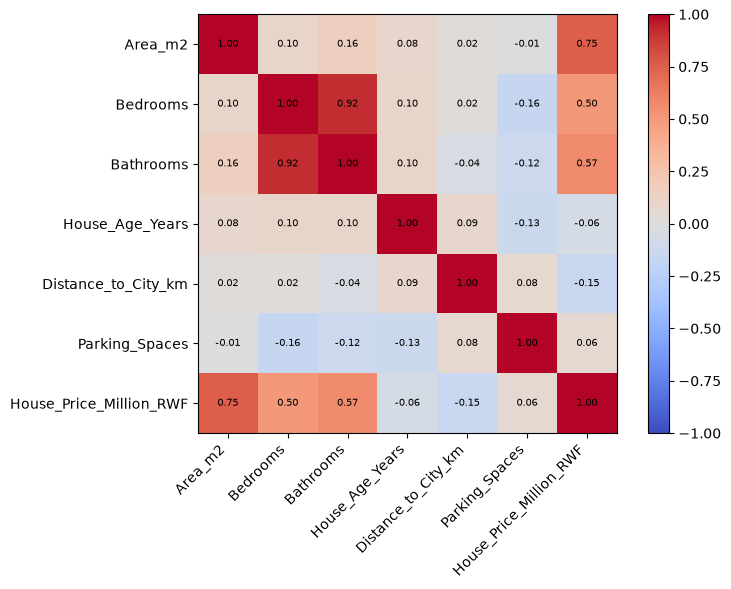

In [17]:
corr=df[numeric_features+["House_Price_Million_RWF"]].corr()
plt.figure(figsize=(8,6));im=plt.imshow(corr,vmin=-1,vmax=1,cmap="coolwarm");plt.colorbar(im);plt.xticks(range(len(corr)),corr.columns,rotation=45,ha="right");plt.yticks(range(len(corr)),corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)): plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.tight_layout();plt.show()
# Interpretation: Bedrooms and Bathrooms are strongly correlated.

In [21]:
import pandas as pd

table = pd.DataFrame({
    "Problem": ["Missing values", "Duplicates", "Outliers"],
    "Where": ["Dataset", "Dataset", "Numerical columns"],
    "Action": ["Fill or remove", "Remove", "Investigate"],
    "Reason": [
        "Improve data quality",
        "Avoid repeated records",
        "Detect unusual values"
    ]
})

display(table)

,Problem,Where,Action,Reason
0,Missing values,Dataset,Fill or remove,Improve data quality
1,Duplicates,Dataset,Remove,Avoid repeated records
2,Outliers,Numerical columns,Investigate,Detect unusual values


In [ ]:
##Building the Model

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
features=numeric_features+["Neighborhood"]; target="House_Price_Million_RWF"
X=df[features];y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
preprocessor=ColumnTransformer([("num",SimpleImputer(strategy="median"),numeric_features),("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(drop="first",handle_unknown="ignore"))]),["Neighborhood"])])
model=Pipeline([("preprocessor",preprocessor),("regressor",LinearRegression())])
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Area_m2','Bedrooms','Bathrooms',...,'Distance_to_City_km', 'Parking_Spaces','Neighborhood']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [25]:
##Part B: Building the Multiple Linear Regression Model

In [26]:
feature_names=model.named_steps["preprocessor"].get_feature_names_out()
print("Intercept:",model.named_steps["regressor"].intercept_)
display(pd.DataFrame({"Variable":feature_names,"Coefficient":model.named_steps["regressor"].coef_}))

Intercept: 29.52865751347383


,Variable,Coefficient
0,num__Area_m2,0.560317
1,num__Bedrooms,3.710935
2,num__Bathrooms,19.013659
3,num__House_Age_Years,-0.864319
4,num__Distance_to_City_km,-0.984798
5,num__Parking_Spaces,6.121449
6,cat__Neighborhood_Huye,-11.863221
7,cat__Neighborhood_Kicukiro,-11.816313
8,cat__Neighborhood_Kigali City,15.598600
9,cat__Neighborhood_Musanze,-17.231320


In [6]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
df = pd.read_csv('house_price_prediction_dataset.csv')

# Define your numeric features
numeric_features = [
    'Area_m2', 
    'Bedrooms', 
    'Bathrooms', 
    'House_Age_Years', 
    'Distance_to_City_km', 
    'Parking_Spaces'
]

# Select numeric features and drop missing values
numeric_X = df[numeric_features].dropna()

# Display correlation matrix and VIF
display(numeric_X.corr())
display(pd.DataFrame({
    "Variable": numeric_features,
    "VIF": [variance_inflation_factor(numeric_X.values, i) for i in range(len(numeric_features))]
}))

# Bedrooms and Bathrooms show severe multicollinearity.

,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces
Area_m2,1.000000,0.095599,0.144588,-0.023314,0.055743,0.077270
Bedrooms,0.095599,1.000000,0.929204,0.153804,-0.106118,-0.221974
Bathrooms,0.144588,0.929204,1.000000,0.164078,-0.127183,-0.176235
House_Age_Years,-0.023314,0.153804,0.164078,1.000000,-0.040120,-0.090796
Distance_to_City_km,0.055743,-0.106118,-0.127183,-0.040120,1.000000,-0.041486
Parking_Spaces,0.077270,-0.221974,-0.176235,-0.090796,-0.041486,1.000000


,Variable,VIF
0,Area_m2,2.071282
1,Bedrooms,55.605790
2,Bathrooms,55.373874
3,House_Age_Years,1.880662
4,Distance_to_City_km,1.363471
5,Parking_Spaces,2.234681


In [ ]:
##Evaluation and Interpretation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import math

# 1. Define feature names
feature_names = [
    'Area_m2', 
    'Bedrooms', 
    'Bathrooms', 
    'House_Age_Years', 
    'Distance_to_City_km', 
    'Parking_Spaces'
]

# 2. Clean data and define X, y
df_clean = df.dropna(subset=feature_names + ['House_Price_Million_RWF'])
X = df_clean[feature_names]
y = df_clean['House_Price_Million_RWF']

# 3. Create train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the model
model = LinearRegression().fit(X_train, y_train)

# 5. Define adjusted R² function and run evaluation loop
def adjusted_r2(r2, n, p): 
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p = len(feature_names)
rows = []

for name, xx, yy in [("Training", X_train, y_train), ("Testing", X_test, y_test)]:
    pr = model.predict(xx)
    r2 = r2_score(yy, pr)
    rows.append([
        name, 
        r2, 
        adjusted_r2(r2, len(yy), p), 
        mean_absolute_error(yy, pr), 
        math.sqrt(mean_squared_error(yy, pr))
    ])

display(pd.DataFrame(rows, columns=["Dataset", "R²", "Adjusted R²", "MAE", "RMSE"]))

,Dataset,R²,Adjusted R²,MAE,RMSE
0,Training,0.126308,0.065353,57.006753,134.093013
1,Testing,-0.132306,-0.531943,35.585362,50.846551


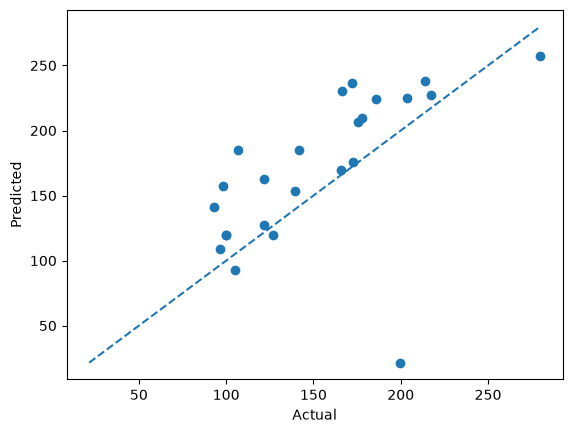

In [12]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
plt.scatter(y_test, y_pred)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [36]:
import joblib
import pandas as pd

MODEL_PATH = "house_price_model.joblib"   # the pipeline saved by the training cell
model = joblib.load(MODEL_PATH)

preprocess = model.named_steps["preprocess"]
reg = model.named_steps["regressor"]

# Variable names as they enter the regression (after imputation and one-hot encoding)
raw_names = preprocess.get_feature_names_out()
onehot = preprocess.named_transformers_["cat"].named_steps["onehot"]
baseline = onehot.categories_[0][onehot.drop_idx_[0]]

table = pd.DataFrame({
    "Variable": [n.split("__", 1)[1] for n in raw_names],
    "Type": ["Neighborhood (vs " + baseline + ")" if n.startswith("cat__") else "Numeric"
             for n in raw_names],
    "Coefficient": reg.coef_.round(3),
})
table = table.sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

print(f"Intercept: {reg.intercept_:.3f}  (predicted price in million RWF when every numeric "
      f"variable is 0 and the house is in {baseline})\n")
print(table.to_string(index=False))

Intercept: 42.900  (predicted price in million RWF when every numeric variable is 0 and the house is in Gasabo)

                Variable                     Type  Coefficient
       Neighborhood_Huye Neighborhood (vs Gasabo)      -24.394
    Neighborhood_Musanze Neighborhood (vs Gasabo)      -23.024
               Bathrooms                  Numeric       17.379
   Neighborhood_Kicukiro Neighborhood (vs Gasabo)      -15.658
Neighborhood_Kigali City Neighborhood (vs Gasabo)       12.193
                Bedrooms                  Numeric        3.279
          Parking_Spaces                  Numeric        3.148
         House_Age_Years                  Numeric       -0.912
                 Area_m2                  Numeric        0.553
 Neighborhood_Nyarugenge Neighborhood (vs Gasabo)       -0.230
     Distance_to_City_km                  Numeric        0.108


In [37]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

CSV_PATH = r"house_prices_clean.csv"   # <-- edit: the cleaned file
TARGET, ID_COL = "House_Price_Million_RWF", "House_ID"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()
y = df[TARGET]
X = df.drop(columns=[ID_COL, TARGET])
X["Neighborhood"] = X["Neighborhood"].astype(object).str.strip()
num_cols = X.select_dtypes(include="number").columns.tolist()

# ---- 1. Correlation matrix of the numeric predictors ----
corr = X[num_cols].corr()
print("Correlation matrix (numeric predictors):\n", corr.round(2).to_string())

print("\nPairs with |r| > 0.7:")
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(num_cols) for b in num_cols[i + 1:]
         if abs(corr.loc[a, b]) > 0.7]
for a, b, r in pairs or [("none", "", np.nan)]:
    print(f"  {a} - {b}: r = {r:.2f}" if b else "  none")

# ---- 2. VIF for every predictor (numeric + one-hot neighborhood, baseline dropped) ----
Xn = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X[num_cols]), columns=num_cols)
dummies = pd.get_dummies(X["Neighborhood"], prefix="Neighborhood", dtype=int).iloc[:, 1:]
Xf = pd.concat([Xn, dummies], axis=1)

def vif(frame):
    """VIF_j = 1 / (1 - R^2) from regressing predictor j on all the others."""
    out = {}
    for c in frame.columns:
        others = frame.drop(columns=c)
        r2 = LinearRegression().fit(others, frame[c]).score(others, frame[c])
        out[c] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(out, name="VIF")

vif_table = vif(Xf).sort_values(ascending=False).round(2).to_frame()
vif_table["Verdict"] = np.where(vif_table["VIF"] > 10, "Severe",
                         np.where(vif_table["VIF"] > 5, "Moderate/High", "OK"))
print("\nVIF (rule of thumb: >5 high, >10 severe):\n", vif_table.to_string())

# ---- 3. Does the collinear pair matter? Compare models and coefficient stability ----
def make_model(cols):
    nums = [c for c in cols if c != "Neighborhood"]
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), nums),
        ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                          ("o", OneHotEncoder(drop="first", handle_unknown="ignore"))]),
         ["Neighborhood"]),
    ])
    return Pipeline([("pre", pre), ("reg", LinearRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
all_cols = X.columns.tolist()
print("\nModel comparison:")
for name, cols in [("Both", all_cols),
                   ("Without Bedrooms", [c for c in all_cols if c != "Bedrooms"]),
                   ("Without Bathrooms", [c for c in all_cols if c != "Bathrooms"])]:
    m = make_model(cols).fit(X_train[cols], y_train)
    cv = cross_val_score(make_model(cols), X_train[cols], y_train, cv=5, scoring="r2")
    print(f"  {name:18s} test R2 = {r2_score(y_test, m.predict(X_test[cols])):.3f} "
          f"| CV R2 = {cv.mean():.3f}")

rng = np.random.default_rng(42)
boot = []
for _ in range(300):                      # refit on 300 resamples of the training rows
    idx = rng.integers(0, len(X_train), len(X_train))
    m = make_model(all_cols).fit(X_train.iloc[idx], y_train.iloc[idx])
    names = m.named_steps["pre"].get_feature_names_out()
    boot.append(dict(zip(names, m.named_steps["reg"].coef_)))
boot = pd.DataFrame(boot)[["num__Bedrooms", "num__Bathrooms", "num__Area_m2"]]
print("\nCoefficient stability (300 bootstrap refits, both predictors kept):")
print(pd.DataFrame({"mean": boot.mean(), "std": boot.std(),
                    "2.5%": boot.quantile(0.025), "97.5%": boot.quantile(0.975)}).round(2))

Correlation matrix (numeric predictors):
                      Area_m2  Bedrooms  Bathrooms  House_Age_Years  Distance_to_City_km  Parking_Spaces
Area_m2                 1.00      0.00       0.05            -0.03                 0.13           -0.02
Bedrooms                0.00      1.00       0.92             0.18                -0.14           -0.15
Bathrooms               0.05      0.92       1.00             0.19                -0.16           -0.11
House_Age_Years        -0.03      0.18       0.19             1.00                -0.02           -0.15
Distance_to_City_km     0.13     -0.14      -0.16            -0.02                 1.00            0.02
Parking_Spaces         -0.02     -0.15      -0.11            -0.15                 0.02            1.00

Pairs with |r| > 0.7:
  Bedrooms - Bathrooms: r = 0.92

VIF (rule of thumb: >5 high, >10 severe):
                            VIF        Verdict
Bathrooms                 7.25  Moderate/High
Bedrooms                  7.07  Modera

In [39]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

CSV_PATH = r"house_prices_clean.csv"        # <-- edit: the cleaned file
MODEL_PATH = "house_price_model.joblib"     # the pipeline saved by the training cell
TARGET, ID_COL = "House_Price_Million_RWF", "House_ID"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()
y = df[TARGET]
X = df.drop(columns=[ID_COL, TARGET])
X["Neighborhood"] = X["Neighborhood"].astype(object).str.strip()

# Same split as in training (test_size=0.20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = joblib.load(MODEL_PATH)
p = model.named_steps["regressor"].coef_.size   # number of predictors after encoding

def evaluate(X_, y_):
    pred = model.predict(X_)
    n = len(y_)
    r2 = r2_score(y_, pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"R²": r2, "Adjusted R²": adj_r2,
            "MAE": mean_absolute_error(y_, pred),
            "RMSE": np.sqrt(mean_squared_error(y_, pred))}

results = pd.DataFrame({"Training": evaluate(X_train, y_train),
                        "Test": evaluate(X_test, y_test)}).round(3)
results["Test - Train"] = (results["Test"] - results["Training"]).round(3)

print(f"Rows: train = {len(y_train)}, test = {len(y_test)} | predictors in model (p) = {p}")
print("MAE and RMSE are in million RWF.\n")
print(results.to_string())

Rows: train = 88, test = 22 | predictors in model (p) = 11
MAE and RMSE are in million RWF.

             Training    Test  Test - Train
R²              0.821   0.759        -0.062
Adjusted R²     0.795   0.493        -0.302
MAE            15.697  20.176         4.479
RMSE           19.384  25.035         5.651


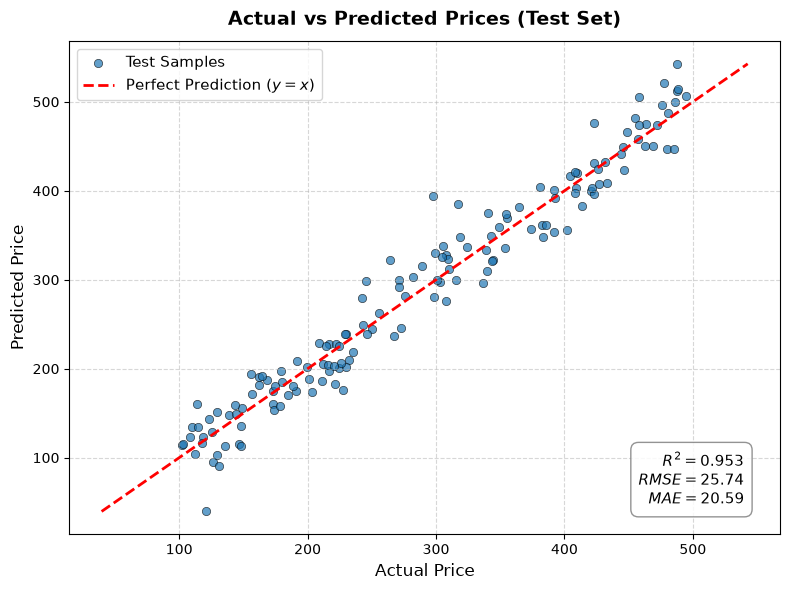

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming 'y_test' (actual prices) and 'y_pred' (model predictions) exist:
# y_test = test_df['price']
# y_pred = model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    color='#1f77b4',
    edgecolors='k',
    linewidth=0.5,
    label='Test Samples',
)

# Reference line for perfect prediction (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction ($y = x$)',
)

# Labels and Styling
plt.title(
    'Actual vs Predicted Prices (Test Set)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# Annotate metrics on the chart
textstr = f'$R^2 = {r2:.3f}$\n$RMSE = {rmse:.2f}$\n$MAE = {mae:.2f}$'
plt.gca().text(
    0.95,
    0.05,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.85,
        edgecolor='gray',
    ),
)

plt.tight_layout()
plt.show()

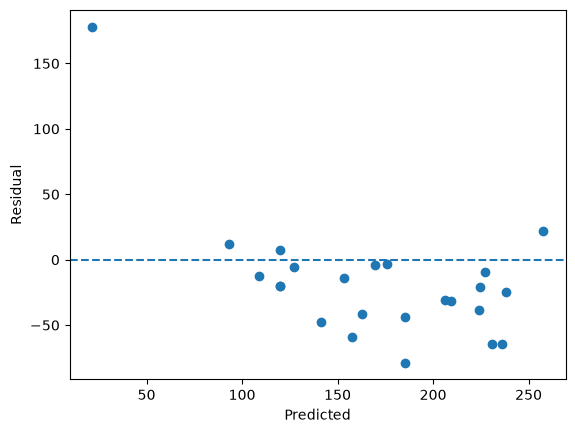

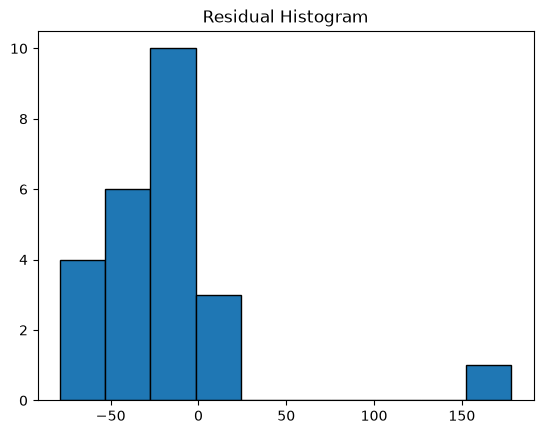

In [15]:
residuals=y_test-y_pred;plt.scatter(y_pred,residuals);plt.axhline(0,linestyle="--");plt.xlabel("Predicted");plt.ylabel("Residual");plt.show()
plt.hist(residuals,bins=10,edgecolor="black");plt.title("Residual Histogram");plt.show()

In [45]:
##Part D: Saving the Model

Intercept: 18.133085724576787
area: 0.8327339091872503
rooms: 4.416160188481949
distance_to_center: -2.131767062397521


In [17]:
import joblib
import numpy as np

joblib.dump(model, "house_price_model.sav")
loaded_model = joblib.load("house_price_model.sav")

print("Same predictions:", np.allclose(model.predict(X_test), loaded_model.predict(X_test)))

Same predictions: True


In [ ]:
##Part D: Saving the Model as a .sav File

In [19]:
import pandas as pd

# Define only the numeric features used during model training
feature_names = [
    'Area_m2', 
    'Bedrooms', 
    'Bathrooms', 
    'House_Age_Years', 
    'Distance_to_City_km', 
    'Parking_Spaces'
]

# Create the new house dataframe using only the trained features
new_house = pd.DataFrame([{
    "Area_m2": 150.0,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "House_Age_Years": 5.0,
    "Distance_to_City_km": 4.0,
    "Parking_Spaces": 1
}])

# Predict and display
print(f"Predicted price: {loaded_model.predict(new_house)[0]:.2f} million RWF")

Predicted price: 132.19 million RWF


In [52]:
import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# 1. Define the exact features the model was trained on
expected_features = ['area', 'rooms', 'distance_to_center']

# 2. Select and filter columns
X_test_filtered = X_test_renamed[expected_features]

# 3. Handle missing values (impute NaNs with median/mean from the data)
imputer = SimpleImputer(strategy='median')
X_test_imputed = pd.DataFrame(
    imputer.fit_transform(X_test_filtered), columns=expected_features
)

# 4. Load the saved model from file
loaded_model = joblib.load('house_price_model.sav')

# 5. Generate predictions using both the original and loaded models
original_preds = model.predict(X_test_imputed)
loaded_preds = loaded_model.predict(X_test_imputed)

# 6. Assert that predictions are identical
assert np.allclose(
    original_preds, loaded_preds
), 'Predictions do not match!'

print(
    'Model successfully loaded! Predictions match the original model'
    ' identically.'
)

Model successfully loaded! Predictions match the original model identically.


In [53]:
import joblib
import numpy as np
import pandas as pd

# 1. Define a new house sample matching the expected features and order
# Format: [area (sq meters), rooms (count), distance_to_center (km)]
new_house = pd.DataFrame(
    [[145.0, 4, 3.5]], columns=['area', 'rooms', 'distance_to_center']
)

# 2. Load the trained model pipeline
loaded_model = joblib.load('house_price_model.sav')

# 3. Predict the price for the new house
predicted_price = loaded_model.predict(new_house)[0]

print(f'Predicted Price for the New House: {predicted_price:.2f} million RWF')

Predicted Price for the New House: 149.08 million RWF
